<a href="https://colab.research.google.com/github/Rakshit-Gupta-77/Machine-Learning-Journey/blob/main/feature_scaling_normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the Dataset

The notebook uses `wine_data.csv`.

We select:
- column `0` → Class label
- column `1` → Alcohol
- column `2` → Malic acid


In [2]:
df = pd.read_csv(
    "wine_data.csv",
    header=None,
    usecols=[0, 1, 2]
)

df.columns = ["Class label", "Alcohol", "Malic acid"]

df.head()


,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


### Parameters of `pd.read_csv()`

- `header=None` → the CSV has no header row, so pandas does not treat the first row as column names.
- `usecols=[0, 1, 2]` → read only columns 0, 1 and 2.


In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())


Shape: (178, 3)

Missing values:
Class label    0
Alcohol        0
Malic acid     0
dtype: int64


## 2. Explore the Data

In [4]:
df


,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


## 3. Feature Distributions

KDE plots show the estimated distribution of a numerical feature.


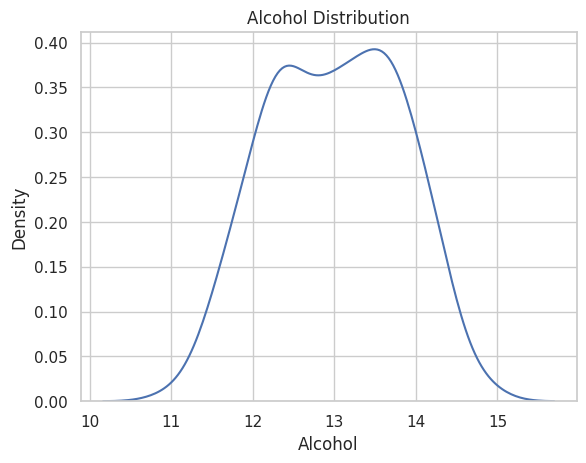

In [5]:
sns.kdeplot(data=df, x="Alcohol")
plt.title("Alcohol Distribution")
plt.show()


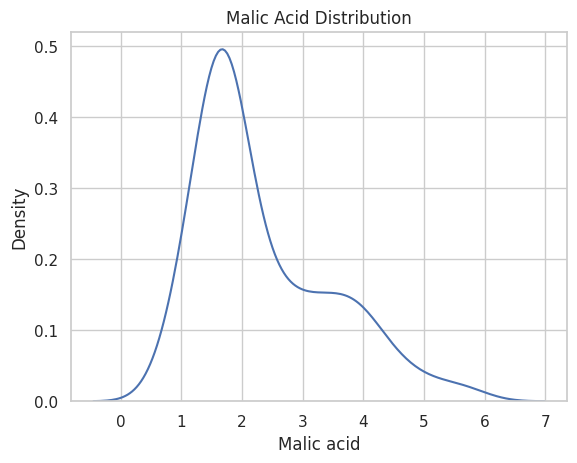

In [6]:
sns.kdeplot(data=df, x="Malic acid")
plt.title("Malic Acid Distribution")
plt.show()


## 4. Scatter Plot by Class

A scatter plot helps us see the relationship between Alcohol and Malic acid.

`hue` separates observations according to the class label.


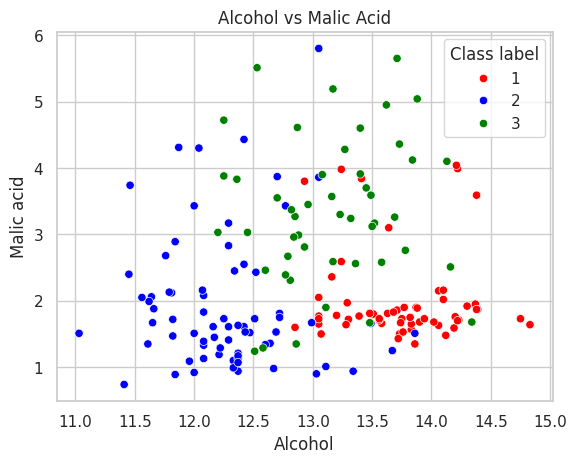

In [7]:
color_dict = {
    1: "red",
    2: "blue",
    3: "green"
}

sns.scatterplot(
    data=df,
    x="Alcohol",
    y="Malic acid",
    hue="Class label",
    palette=color_dict
)

plt.title("Alcohol vs Malic Acid")
plt.show()


## 5. Train-Test Split

We separate:
- `X` → features
- `y` → target/class

Then use 70% for training and 30% for testing.


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("Class label", axis=1)
y = df["Class label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (124, 2)
X_test : (54, 2)
y_train: (124,)
y_test : (54,)


### Important

`test_size=0.30` means:
- 70% → training
- 30% → testing

`random_state=0` makes the split reproducible.


# 6. Min-Max Scaling

**Min-Max Scaling** converts each feature to a fixed range, usually **0 to 1**.

### Formula

$$
X' = \frac{X-X_{min}}{X_{max}-X_{min}}
$$

After scaling:

- minimum value ≈ `0`
- maximum value ≈ `1`

Unlike Standardization, Min-Max Scaling does **not** make the mean 0 and standard deviation 1.


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Learn min and max values from training data only
scaler.fit(X_train)

# Apply the learned transformation
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


### `MinMaxScaler()`

Creates the scaler.

### `fit(X_train)`

Learns the minimum and maximum values from the training data.

### `transform(X_train)`

Uses the learned minimum and maximum values to scale training data.

### `transform(X_test)`

Uses the **same training-data parameters** to scale test data.

> Never fit the scaler separately on the test set.


In [10]:
print("Minimum values learned from training data:")
print(scaler.data_min_)

print("\nMaximum values learned from training data:")
print(scaler.data_max_)


Minimum values learned from training data:
[11.03  0.89]

Maximum values learned from training data:
[14.75  5.65]


## 7. Convert Scaled Data Back to DataFrames

`MinMaxScaler` returns a NumPy array. Converting it back to a DataFrame makes the output easier to inspect.


In [11]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()


,Alcohol,Malic acid
22,0.720430,0.203782
108,0.319892,0.084034
175,0.602151,0.712185
145,0.572581,0.563025
71,0.760753,0.130252


## 8. Compare Statistics Before and After Scaling

In [12]:
print("Before scaling:")
display(np.round(X_train.describe(), 2))

print("\nAfter Min-Max scaling:")
display(np.round(X_train_scaled.describe(), 2))


Before scaling:


,Alcohol,Malic acid
count,124.00,124.00
mean,12.98,2.38
std,0.80,1.14
min,11.03,0.89
25%,12.36,1.61
50%,13.04,1.88
75%,13.64,3.25
max,14.75,5.65



After Min-Max scaling:


,Alcohol,Malic acid
count,124.00,124.00
mean,0.53,0.31
std,0.22,0.24
min,0.00,0.00
25%,0.36,0.15
50%,0.54,0.21
75%,0.70,0.50
max,1.00,1.00


### Important observation

After Min-Max scaling, the values are generally between **0 and 1**.

The mean does **not** necessarily become 0.

That is the main difference from Standardization.


## 9. Scatter Plot — Before vs After Scaling

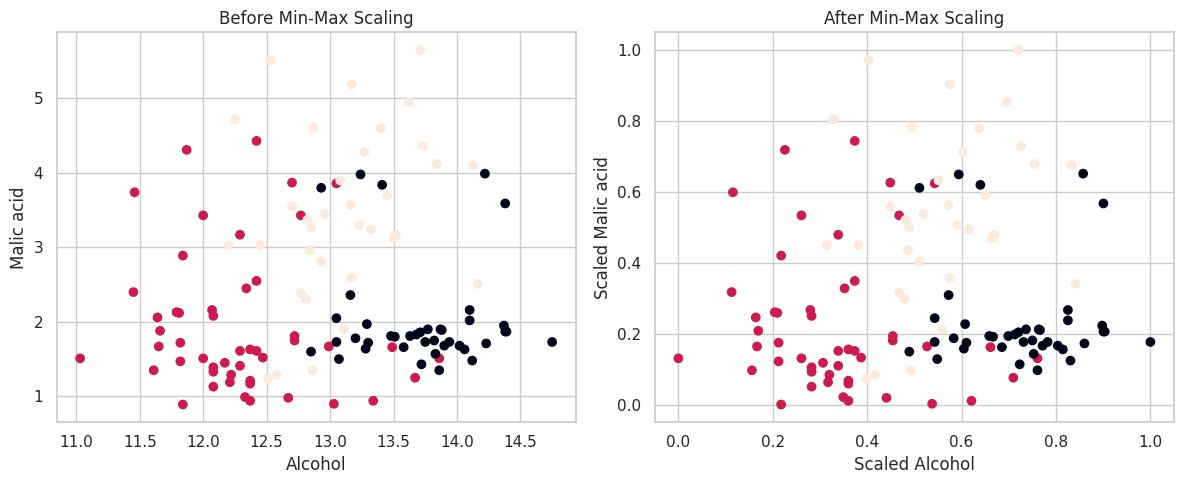

In [13]:
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5)
)

ax1.scatter(
    X_train["Alcohol"],
    X_train["Malic acid"],
    c=y_train
)
ax1.set_title("Before Min-Max Scaling")
ax1.set_xlabel("Alcohol")
ax1.set_ylabel("Malic acid")

ax2.scatter(
    X_train_scaled["Alcohol"],
    X_train_scaled["Malic acid"],
    c=y_train
)
ax2.set_title("After Min-Max Scaling")
ax2.set_xlabel("Scaled Alcohol")
ax2.set_ylabel("Scaled Malic acid")

plt.tight_layout()
plt.show()


## 10. Distribution Comparison

Scaling changes the numerical range of a feature but does not change the basic ordering of observations.


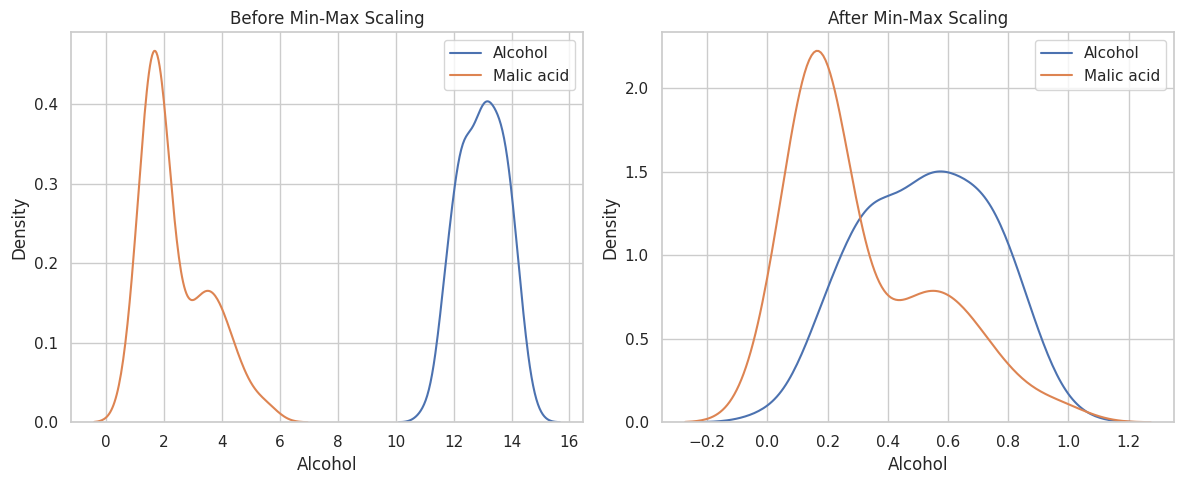

In [14]:
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5)
)

ax1.set_title("Before Min-Max Scaling")
sns.kdeplot(data=X_train, x="Alcohol", ax=ax1, label="Alcohol")
sns.kdeplot(data=X_train, x="Malic acid", ax=ax1, label="Malic acid")
ax1.legend()

ax2.set_title("After Min-Max Scaling")
sns.kdeplot(data=X_train_scaled, x="Alcohol", ax=ax2, label="Alcohol")
sns.kdeplot(data=X_train_scaled, x="Malic acid", ax=ax2, label="Malic acid")
ax2.legend()

plt.tight_layout()
plt.show()


## 11. Alcohol — Before vs After Scaling

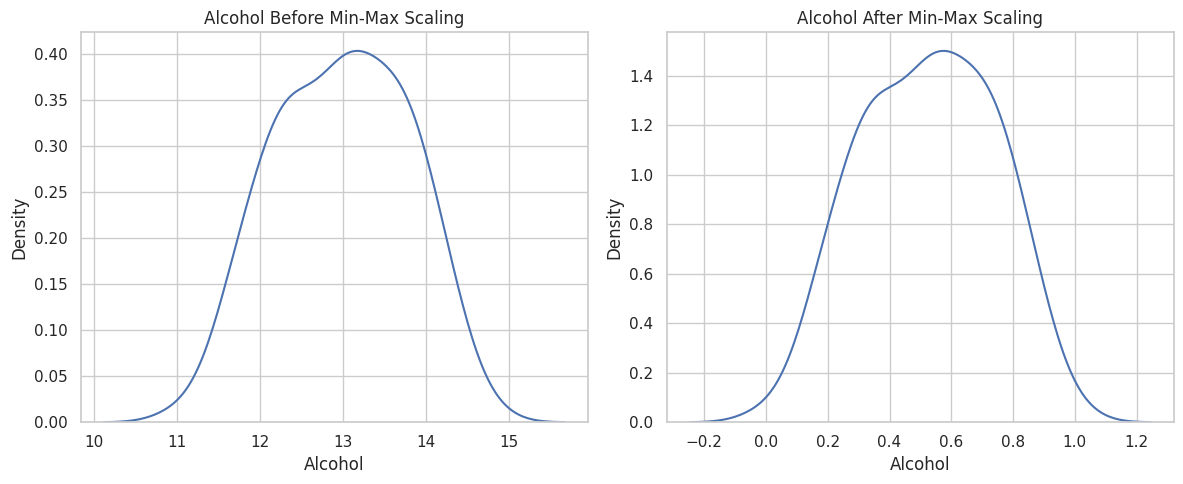

In [15]:
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5)
)

sns.kdeplot(data=X_train, x="Alcohol", ax=ax1)
ax1.set_title("Alcohol Before Min-Max Scaling")

sns.kdeplot(data=X_train_scaled, x="Alcohol", ax=ax2)
ax2.set_title("Alcohol After Min-Max Scaling")

plt.tight_layout()
plt.show()


## 12. Malic Acid — Before vs After Scaling

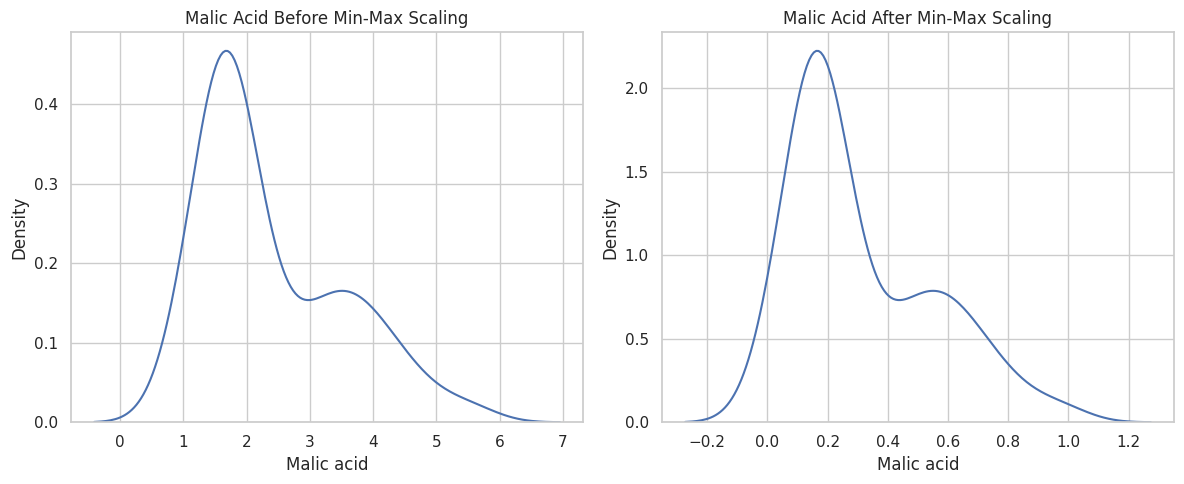

In [16]:
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(12, 5)
)

sns.kdeplot(data=X_train, x="Malic acid", ax=ax1)
ax1.set_title("Malic Acid Before Min-Max Scaling")

sns.kdeplot(data=X_train_scaled, x="Malic acid", ax=ax2)
ax2.set_title("Malic Acid After Min-Max Scaling")

plt.tight_layout()
plt.show()


# 13. Min-Max Scaling vs Standardization

| Min-Max Scaling | Standardization |
|---|---|
| Uses minimum and maximum | Uses mean and standard deviation |
| Formula: `(x-min)/(max-min)` | Formula: `(x-mean)/std` |
| Usually gives range 0–1 | Mean ≈ 0, Std ≈ 1 |
| Sensitive to outliers | Also sensitive to outliers |
| Uses `MinMaxScaler` | Uses `StandardScaler` |

### Quick memory trick

**Min-Max → minimum + maximum → usually 0 to 1**

**Standardization → mean + standard deviation → mean 0, SD 1**


# 14. Final Revision Notes

### Min-Max Scaling
- A feature scaling technique.
- Converts features to a fixed range, normally 0 to 1.
- Formula:

$$
X' = \frac{X-X_{min}}{X_{max}-X_{min}}
$$

### Python
```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

### Important rule
**Fit on training data → transform training and test data using the same scaler.**

### Remember
- `fit()` → learn min and max
- `transform()` → apply scaling
- `fit_transform()` → fit + transform
- Min-Max does **not** make mean 0.
- Standardization does **not** necessarily make values lie between 0 and 1.


# 15. Quick Revision Questions

1. What is Min-Max Scaling?
2. Write its formula.
3. What is the usual output range?
4. What does `fit()` learn in `MinMaxScaler`?
5. Why should we not fit the scaler on test data?
6. What is the difference between Min-Max Scaling and Standardization?
7. What does `test_size=0.30` mean?
8. What is the purpose of `random_state`?
